# Interpreting Detectron2 Instance Segmentation Models

This notebook demonstrates how to attribute a Detectron2 Mask R-CNN instance mask prediction with Captum. The example uses Detectron2's COCO Mask R-CNN R50-FPN model because it preserves the `Instances.pred_masks`, `pred_boxes`, and `pred_classes` output structure commonly used in Detectron2 instance-segmentation workflows.

**Note:** Before running this tutorial, please install Detectron2, torchvision, Pillow, matplotlib, and setuptools<82.

In [1]:
import numpy as np
import torch
from PIL import Image

from detectron2 import model_zoo
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.config import get_cfg
from detectron2.modeling import build_model
from detectron2.structures import Boxes, Instances

from captum.attr import IntegratedGradients, visualization as viz

/home/craymichael/Projects/captum/venv/uv/lib64/python3.12/site-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/craymichael/Projects/captum/venv/uv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the Mask R-CNN model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
)
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.DEVICE = device

model = build_model(cfg)
DetectionCheckpointer(model).load(cfg.MODEL.WEIGHTS)
_ = model.eval()

## Run detection once and select an instance

The attribution target should stay fixed while Captum perturbs the image. We first run detection on the original image, choose one predicted instance, and then reuse that instance's box and class when scoring perturbed images.

In [3]:
image = Image.open("img/vqa/zebra.jpg").convert("RGB")
rgb_image = np.asarray(image)
height, width = rgb_image.shape[:2]

# Detectron2 models expect BGR channel order with pixel values in [0, 255].
bgr_image = rgb_image[:, :, ::-1].copy()
image_tensor = torch.as_tensor(
    bgr_image.transpose(2, 0, 1), dtype=torch.float32, device=device
)

with torch.no_grad():
    outputs = model([{"image": image_tensor, "height": height, "width": width}])[0]

instances = outputs["instances"].to("cpu")
print(instances)

instance_idx = 0
selected_box = instances.pred_boxes[instance_idx].tensor.to(device)
selected_class = int(instances.pred_classes[instance_idx].item())
selected_score = float(instances.scores[instance_idx].item())

print("Selected class id:", selected_class)
print("Selected score:", selected_score)

/home/craymichael/Projects/captum/venv/uv/lib64/python3.12/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Instances(num_instances=3, image_height=1536, image_width=2048, fields=[pred_boxes: Boxes(tensor([[ 232.4499,  411.5759, 1531.9014, 1322.0845],
        [ 829.5202,  393.7237, 1943.5859,  969.2655],
        [ 871.8043,  457.9581, 1435.5551, 1305.6792]])), scores: tensor([0.9778, 0.9736, 0.5887]), pred_classes: tensor([22, 22, 22]), pred_masks: tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ...

## Define a differentiable fixed-instance mask score

The wrapper below avoids changing which instance is being explained when the image is perturbed. It uses the backbone features from each perturbed image, pools features for the fixed box selected above, runs the Mask R-CNN mask head, and returns the selected class mask probability summed over the 28 x 28 mask logits.

In [4]:
def fixed_instance_mask_score(image_batch):
    scores = []
    for image_chw in image_batch:
        model_inputs = [{"image": image_chw, "height": height, "width": width}]
        images = model.preprocess_image(model_inputs)
        features = model.backbone(images.tensor)

        feature_maps = [features[name] for name in model.roi_heads.in_features]
        mask_features = model.roi_heads.mask_pooler(
            feature_maps,
            [Boxes(selected_box)],
        )
        target_instances = Instances((height, width))
        target_instances.pred_boxes = Boxes(selected_box)
        target_instances.pred_classes = torch.tensor([selected_class], device=device)
        mask_instances = model.roi_heads.mask_head(
            mask_features,
            [target_instances],
        )[0]

        scores.append(mask_instances.pred_masks.sum())

    return torch.stack(scores)

## Attribute the selected mask score to input pixels

In [5]:
ig = IntegratedGradients(fixed_instance_mask_score)

input_batch = image_tensor.unsqueeze(0)
baseline = torch.zeros_like(input_batch)

attributions, delta = ig.attribute(
    input_batch,
    baselines=baseline,
    n_steps=24,
    internal_batch_size=4,
    return_convergence_delta=True,
)

print("Attribution shape:", tuple(attributions.shape))
print("Convergence delta:", delta)

Attribution shape: (1, 3, 1536, 2048)
Convergence delta: tensor([-413.2216])


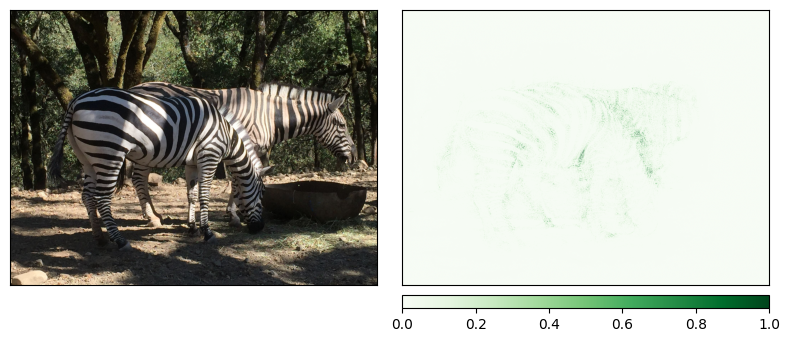

In [6]:
attr_rgb = attributions.squeeze(0).detach().cpu()[[2, 1, 0]].permute(1, 2, 0).numpy()
original_rgb = image_tensor.detach().cpu()[[2, 1, 0]].permute(1, 2, 0).numpy() / 255.0

_ = viz.visualize_image_attr_multiple(
    attr_rgb,
    original_rgb,
    methods=["original_image", "heat_map"],
    signs=["all", "positive"],
    show_colorbar=True,
    outlier_perc=2,
)